# Quantium Retail Exploratory Data Analysis

In [37]:
# -----------------------
# 1. Import dependencies
# -----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pandas display settings
pd.set_option('display.max_columns', None)

In [48]:
# -----------------------
# 2. Load datasets
# -----------------------

transaction_df = pd.read_excel(file_path + "QVI_transaction_data.xlsx")
customer_df = pd.read_csv("QVI_purchase_behaviour.csv")

In [49]:
# -----------------------
# 3. Exploratory Data Analysis
# -----------------------

# Preview datasets
print(transaction_df.head())
print(transaction_df.info())
print(customer_df.head())
print(customer_df.info())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   ST

In [20]:
# Checking for Null Values
print("Transaction data: ", transaction_df.isnull().sum())
print("Customer data: ", customer_df.isnull().sum())

Transaction data:  DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64
Customer data:  LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


The datasets has no null values

In [50]:
#Checking for duplicate values 
print("Transaction data: ", transaction_df.duplicated().sum())
print("Customer data: ", customer_df.duplicated().sum())

Transaction data:  1
Customer data:  0


Their is only one duplicate value in transaction dataset

In [51]:
#Removing duplicates
transaction_df.drop_duplicates(inplace=True)

#After removing duplicates
print("Transaction data After removing duplicates: ", transaction_df.duplicated().sum())

Transaction data After removing duplicates:  0


In [53]:
# -----------------------
# 3a. Convert DATE column
# ----------------------- 
transaction_df['DATE'] = pd.to_datetime(transaction_df['DATE'], origin='1899-12-30')

Date column is converted into proper date format to analyze different trends over time

In [55]:
# -----------------------
# 3b. Inspect product names
# -----------------------
transaction_df['PROD_NAME'].value_counts().head()

# extract all unique words for checking non-chip items
all_words = " ".join(transaction_df['PROD_NAME']).split()
unique_words = pd.Series(all_words).value_counts()
print(unique_words.head(20))


175g        60560
Chips       49770
150g        41633
Kettle      41288
&           35565
Smiths      28859
Salt        27976
Cheese      27890
134g        25102
Pringles    25102
Doritos     24962
Crinkle     23960
110g        22387
Corn        22063
Original    21560
Cut         20753
Chip        18645
170g        18502
Salsa       18094
Chicken     15406
Name: count, dtype: int64


In [61]:
# Remove any products with 'salsa' in the name (case-insensitive)
transaction_df = transaction_df[~transaction_df['PROD_NAME'].str.contains("salsa", case=False)]

Removing salsa product because it is not included in chips

In [59]:
# Extract the numeric value (pack size in grams)
transaction_df['PACK_SIZE'] = transaction_df['PROD_NAME'].str.extract(r'(\d+)').astype(float)

Converted string values into float for better analysis

In [63]:
# Extract Brand names
# Take first word as brand
transaction_df['BRAND'] = transaction_df['PROD_NAME'].apply(lambda x: x.split()[0].upper())

# Clean any known duplicates (optional)
transaction_df['BRAND'] = transaction_df['BRAND'].replace({
    "RED": "RRD",       
    "NATURAL": "NATURA"
})

We take the first word of PROD_NAME as the brand to standardize naming

In [65]:
# Example: remove pack size and brand, keep the rest as flavor
transaction_df['FLAVOR'] = transaction_df['PROD_NAME'].str.replace(r'\d+g', '', regex=True)
#transaction_df['FLAVOR'] = transaction_df['FLAVOR'].str.replace(transaction_df['BRAND'], '', regex=True).str.strip()

In [67]:
transaction_df[['PROD_NAME','BRAND','PACK_SIZE','FLAVOR']]

,PROD_NAME,BRAND,PACK_SIZE,FLAVOR
0,Natural Chip Compny SeaSalt175g,NATURA,175.0,Natural Chip Compny SeaSalt
1,CCs Nacho Cheese 175g,CCS,175.0,CCs Nacho Cheese
2,Smiths Crinkle Cut Chips Chicken 170g,SMITHS,170.0,Smiths Crinkle Cut Chips Chicken
3,Smiths Chip Thinly S/Cream&Onion 175g,SMITHS,175.0,Smiths Chip Thinly S/Cream&Onion
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,KETTLE,150.0,Kettle Tortilla ChpsHny&Jlpno Chili
...,...,...,...,...
264831,Kettle Sweet Chilli And Sour Cream 175g,KETTLE,175.0,Kettle Sweet Chilli And Sour Cream
264832,Tostitos Splash Of Lime 175g,TOSTITOS,175.0,Tostitos Splash Of Lime
264833,Doritos Mexicana 170g,DORITOS,170.0,Doritos Mexicana
264834,Doritos Corn Chip Mexican Jalapeno 150g,DORITOS,150.0,Doritos Corn Chip Mexican Jalapeno


In [58]:
all_words = " ".join(transaction_df['PROD_NAME']).split()
unique_words = pd.Series(all_words).value_counts()
unique_words

175g       60560
Chips      49770
150g       41633
Kettle     41288
&          35565
           ...  
Whlegrn     1432
Pc          1431
NCC         1419
Garden      1419
Fries       1418
Name: count, Length: 220, dtype: int64

In [71]:
# -----------------------
# 3c. Summary for nulls & outliers
# -----------------------
print(transaction_df.describe())

                                DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                         246741  246741.000000    2.467410e+05   
mean   1899-12-30 00:00:00.000043264     135.051212    1.355311e+05   
min    1899-12-30 00:00:00.000043282       1.000000    1.000000e+03   
25%    1899-12-30 00:00:00.000043264      70.000000    7.001500e+04   
50%    1899-12-30 00:00:00.000043520     130.000000    1.303670e+05   
75%    1899-12-30 00:00:00.000043520     203.000000    2.030840e+05   
max    1899-12-30 00:00:00.000043646     272.000000    2.373711e+06   
std                              NaN      76.787231    8.071542e+04   

             TXN_ID       PROD_NBR       PROD_QTY      TOT_SALES  \
count  2.467410e+05  246741.000000  246741.000000  246741.000000   
mean   1.351312e+05      56.351835       1.908061       7.321328   
min    1.000000e+00       1.000000       1.000000       1.700000   
25%    6.756900e+04      26.000000       2.000000       5.800000   
50%    1.351840e+05 

In [81]:
# Investigate the outlier (quantity = 200)
outliers = transaction_df[transaction_df['PROD_QTY'] == 200]
print(outliers)

Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES, PACK_SIZE, BRAND, FLAVOR]
Index: []


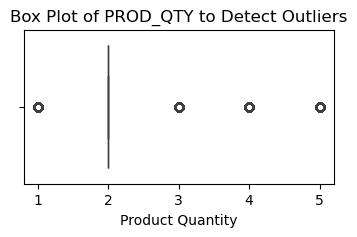

In [79]:
# Box plot using Seaborn
# plt.figure(figsize=(4, 2))
# sns.boxplot(x=transaction_df['PROD_QTY'])
# plt.title('Box Plot of PROD_QTY to Detect Outliers')
# plt.xlabel('Product Quantity')
# plt.show()

In [74]:
# -----------------------
# 3d. Remove suspicious customer
# -----------------------
customer_id_to_remove = outliers['LYLTY_CARD_NBR'].iloc[0]
transaction_df = transaction_df[transaction_df['LYLTY_CARD_NBR'] != customer_id_to_remove]


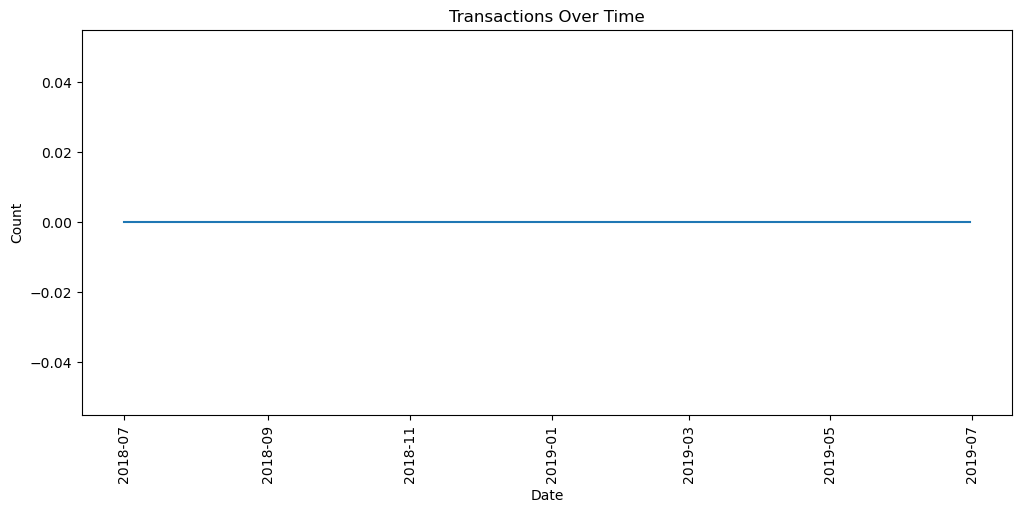

In [80]:
# -----------------------
# 3f. Transactions over time
# -----------------------
transactions_by_date = transaction_df.groupby('DATE').size().reset_index(name="count")

# create full date range
full_dates = pd.DataFrame({"DATE": pd.date_range("2018-07-01", "2019-06-30")})

# left merge to identify missing days
transactions_by_date = full_dates.merge(transactions_by_date, on="DATE", how="left").fillna(0)

# Plot time series
plt.figure(figsize=(12,5))
plt.plot(transactions_by_date['DATE'], transactions_by_date['count'])
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Data Visualization

C:\Users\freel\AppData\Local\Temp\ipykernel_208\4196795119.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['PACK_SIZE'] = transaction_df['PROD_NAME'].str.extract(r'(\d+)').astype(int)


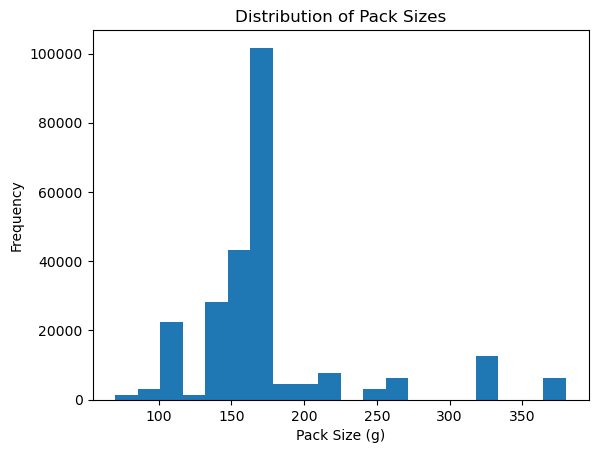

In [84]:
# -----------------------
# 3g. Extract pack size
# -----------------------
transaction_df['PACK_SIZE'] = transaction_df['PROD_NAME'].str.extract(r'(\d+)').astype(int)

# Histogram of pack sizes
plt.hist(transaction_df['PACK_SIZE'], bins=20)
plt.title("Distribution of Pack Sizes")
plt.xlabel("Pack Size (g)")
plt.ylabel("Frequency")
plt.show()


This shows that which type of pack sizes are common among customers

In [91]:
#transaction_df['BRAND'].unique()

C:\Users\freel\AppData\Local\Temp\ipykernel_208\1296121972.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['BRAND'] = transaction_df['PROD_NAME'].apply(lambda x: x.split()[0].upper())
C:\Users\freel\AppData\Local\Temp\ipykernel_208\1296121972.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['BRAND'] = transaction_df['BRAND'].replace(brand_corrections)
C:\Users\freel\AppData\Local\Temp\ipykernel_208\1296121972.py:39: FutureWarning: 

Passing `palette` without assigning `

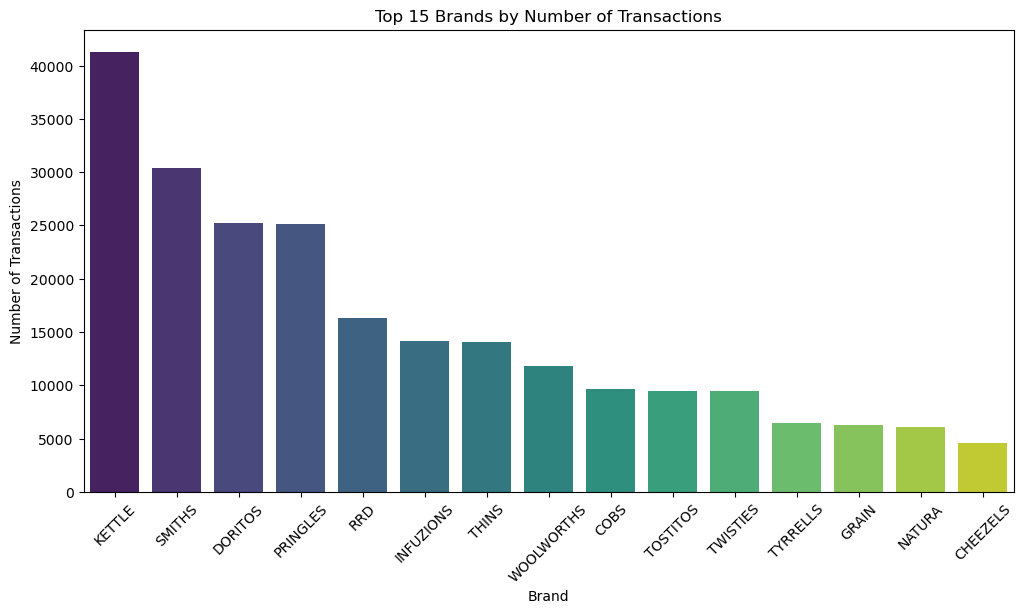

In [90]:
# -----------------------
# 3h. Extract brand name
# -----------------------
# Take the first word of PROD_NAME as brand
transaction_df['BRAND'] = transaction_df['PROD_NAME'].apply(lambda x: x.split()[0].upper())

# -----------------------
# Brand cleanup
# -----------------------
brand_corrections = {
    "RED": "RRD",
    "NATURAL": "NATURA",
    "SMITH": "SMITHS",
    "DORITO": "DORITOS",
    "INFZNS": "INFUZIONS",
    "BURGER": "BURGER RINGS",  # example, adjust if needed
    "SNBTS": "SUNBITES",
    "CCS": "CC'S",
    "WW": "WOOLWORTHS"
    # add more corrections as you notice inconsistencies
}

transaction_df['BRAND'] = transaction_df['BRAND'].replace(brand_corrections)

# -----------------------
# Count transactions per brand
# -----------------------
brand_counts = transaction_df['BRAND'].value_counts().reset_index()
brand_counts.columns = ['BRAND', 'Transactions']

# -----------------------
# Visualization: Top 15 brands
# -----------------------
plt.figure(figsize=(12,6))
sns.barplot(data=brand_counts.head(15), x='BRAND', y='Transactions', palette='viridis')
plt.title("Top 15 Brands by Number of Transactions")
plt.xlabel("Brand")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()


Plot top brands to understand customer preferences

In [92]:
# -----------------------
# 4. Merge customer data for customer based transaction analysis
# -----------------------
merged_df = transaction_df.merge(customer_df, on="LYLTY_CARD_NBR", how="left")

# check for unmatched customers
print(merged_df.isnull().sum())


DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
FLAVOR              0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


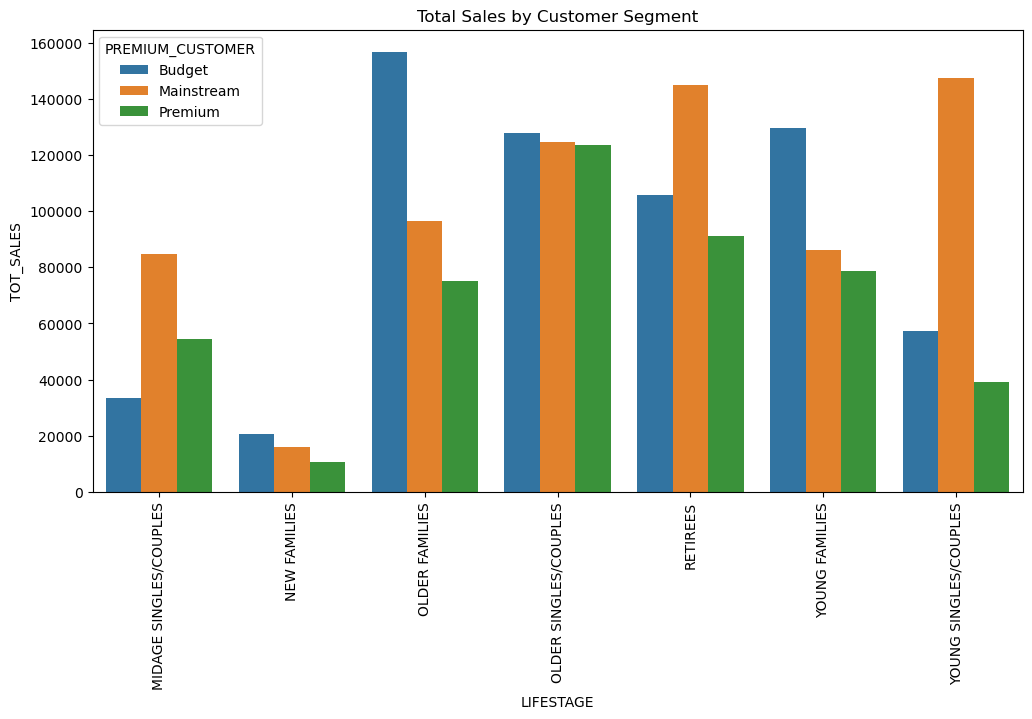

In [93]:
# -----------------------
# 5. Customer segment analysis
# -----------------------

# Total sales by lifestage & premium category
sales_summary = (
    merged_df
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg({'TOT_SALES': 'sum'})
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=90)
plt.title("Total Sales by Customer Segment")
plt.show()

This shows which type of cutomers are premium members and identify their buying patterns

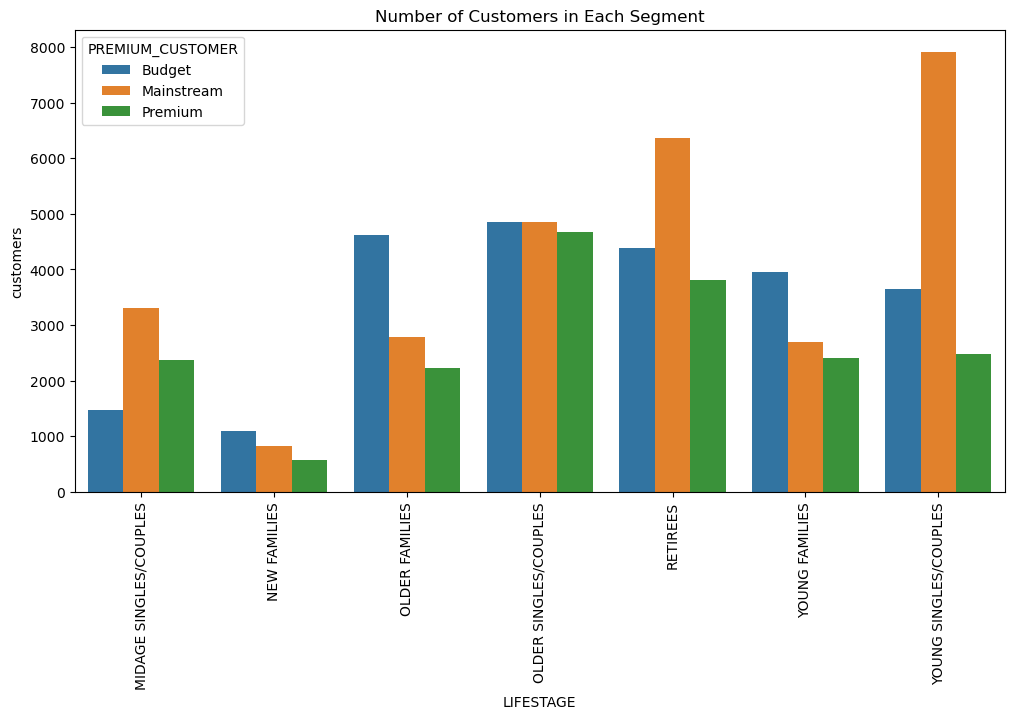

In [94]:
# -----------------------
# 6. Number of customers per segment
# -----------------------
customer_counts = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='customers')
)

plt.figure(figsize=(12,6))
sns.barplot(data=customer_counts, x='LIFESTAGE', y='customers', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=90)
plt.title("Number of Customers in Each Segment")
plt.show()

In [102]:
# -----------------------
# 7. Additional metrics
# -----------------------

# Chips bought per customer
chips_per_customer = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()
)
print("Chips bought per customer: ")
print(chips_per_customer)

Chips bought per customer: 
                 LIFESTAGE PREMIUM_CUSTOMER  PROD_QTY
0   MIDAGE SINGLES/COUPLES           Budget      8883
1   MIDAGE SINGLES/COUPLES       Mainstream     21213
2   MIDAGE SINGLES/COUPLES          Premium     14400
3             NEW FAMILIES           Budget      5241
4             NEW FAMILIES       Mainstream      4060
5             NEW FAMILIES          Premium      2769
6           OLDER FAMILIES           Budget     41853
7           OLDER FAMILIES       Mainstream     25804
8           OLDER FAMILIES          Premium     20239
9    OLDER SINGLES/COUPLES           Budget     32883
10   OLDER SINGLES/COUPLES       Mainstream     32607
11   OLDER SINGLES/COUPLES          Premium     31693
12                RETIREES           Budget     26932
13                RETIREES       Mainstream     37677
14                RETIREES          Premium     23266
15          YOUNG FAMILIES           Budget     34482
16          YOUNG FAMILIES       Mainstream     23194


In [103]:
# Average price per segment
average_price = (
    merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().reset_index()
)
print("Average price per segment: ")
print(average_price)

Average price per segment: 
                 LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
0   MIDAGE SINGLES/COUPLES           Budget   7.108442
1   MIDAGE SINGLES/COUPLES       Mainstream   7.637156
2   MIDAGE SINGLES/COUPLES          Premium   7.152371
3             NEW FAMILIES           Budget   7.297256
4             NEW FAMILIES       Mainstream   7.313364
5             NEW FAMILIES          Premium   7.231720
6           OLDER FAMILIES           Budget   7.291241
7           OLDER FAMILIES       Mainstream   7.281440
8           OLDER FAMILIES          Premium   7.232779
9    OLDER SINGLES/COUPLES           Budget   7.444305
10   OLDER SINGLES/COUPLES       Mainstream   7.306049
11   OLDER SINGLES/COUPLES          Premium   7.460085
12                RETIREES           Budget   7.445786
13                RETIREES       Mainstream   7.269352
14                RETIREES          Premium   7.461315
15          YOUNG FAMILIES           Budget   7.302705
16          YOUNG FAMILIES       Main

In [104]:
# -----------------------
# 8. Save cleaned data
# -----------------------
merged_df.to_csv(file_path + "QVI_data_cleaned_python.csv", index=False)